# Panic Prediction - Classification Model

This notebook applies the **Classification Modeling Skill** to predict panic events from alert data.

## Workflow Overview

| Step | Task | Status |
|------|------|--------|
| 1 | Data Preparation | ⬜ |
| 2 | Feature Engineering | ⬜ |
| 3 | Train/Test Split | ⬜ |
| 4 | Handle Class Imbalance | ⬜ |
| 5 | Model Selection & Training | ⬜ |
| 6 | Cross-Validation | ⬜ |
| 7 | Hyperparameter Tuning | ⬜ |
| 8 | Model Evaluation | ⬜ |
| 9 | Feature Importance | ⬜ |
| 10 | Model Comparison | ⬜ |
| 11 | Model Persistence | ⬜ |
| 12 | Summary Report | ⬜ |

---

## Section 1: Import Required Libraries

Import all necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn - Preprocessing
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# Scikit-learn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Model Persistence
import joblib

# Optional Libraries (install if needed)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    print("XGBoost not installed. Install with: pip install xgboost")
    HAS_XGBOOST = False

try:
    from imblearn.over_sampling import SMOTE
    HAS_IMBLEARN = True
except ImportError:
    print("imbalanced-learn not installed. Install with: pip install imbalanced-learn")
    HAS_IMBLEARN = False

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

imbalanced-learn not installed. Install with: pip install imbalanced-learn
✓ All libraries imported successfully


## Section 2: Load and Explore Dataset

Load your classification dataset and perform initial exploration to understand its structure.

In [4]:
# ============================================================================
# CONFIGURATION - UPDATE THESE VALUES
# ============================================================================
DATA_FILE = "final_feature_matrix_balanced.csv"  # Path to your dataset
TARGET_COLUMN = "label"        # Name of target column (0=no panic, 1=panic)
ID_COLUMNS = ["event_id", "serialnumber"]  # Columns to drop (identifiers)
TEST_SIZE = 0.2               # Test set proportion
RANDOM_STATE = 42             # Random seed for reproducibility

# ============================================================================
# Load Data
# ============================================================================
df = pd.read_csv(DATA_FILE)

# Drop identifier columns (not features)
df = df.drop(columns=[c for c in ID_COLUMNS if c in df.columns], errors='ignore')

print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"🎯 Target Column: {TARGET_COLUMN}")
print(f"\n📋 Column Types:")
print(df.dtypes.value_counts())

df.head()

📊 Dataset Shape: 1,070 rows × 1606 columns
🎯 Target Column: label

📋 Column Types:
int64      1047
float64     558
str           1
Name: count, dtype: int64


,label,alert_days_with_alerts,alert_has_data,alert_total_count_t1,alert_total_count_t2,alert_total_count_t3,alert_total_count_t4,alert_total_count_t5,alert_total_count_t6,alert_total_count_t7,...,memproc_distinct_process_states_std,has_data_systems,has_data_nodes,has_data_alerts,has_data_events,has_data_heartbeat,has_data_evtlogentry,has_data_memdataproc,has_data_memdataslab,tables_with_data
0,0,1,1,0,0,0,1,0,0,0,...,1.000000,1,1,1,1,1,1,1,1,8
1,0,6,1,0,1,2,1,1,1,1,...,0.534522,1,1,1,1,1,1,1,1,8
2,1,2,1,1,0,0,0,0,0,6,...,0.377964,1,1,1,1,1,1,1,1,8
3,0,0,0,0,0,0,0,0,0,0,...,0.755929,1,1,1,1,1,1,1,1,8
4,0,0,0,0,0,0,0,0,0,0,...,1.718249,1,1,1,1,1,1,1,1,8


In [5]:
# Data Quality Assessment
print("📋 Data Quality Report")
print("=" * 50)
print(f"\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print(f"\n🔍 Duplicates: {df.duplicated().sum():,}")
print(f"\n📊 Statistical Summary:")
df.describe()

📋 Data Quality Report

🔍 Missing Values:
Empty DataFrame
Columns: [Missing, Percent]
Index: []

🔍 Duplicates: 0

📊 Statistical Summary:


,label,alert_days_with_alerts,alert_has_data,alert_total_count_t1,alert_total_count_t2,alert_total_count_t3,alert_total_count_t4,alert_total_count_t5,alert_total_count_t6,alert_total_count_t7,...,memproc_distinct_process_states_std,has_data_systems,has_data_nodes,has_data_alerts,has_data_events,has_data_heartbeat,has_data_evtlogentry,has_data_memdataproc,has_data_memdataslab,tables_with_data
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,...,1070.000000,1070.000000,1070.000000,1070.0,1070.0,1070.000000,1070.0,1070.000000,1070.000000,1070.000000
mean,0.500000,1.962617,0.578505,9.493458,9.505607,8.957944,8.940187,8.957944,8.756075,11.868224,...,0.829575,0.998131,0.999065,1.0,1.0,0.999065,1.0,0.996262,0.996262,7.988785
std,0.500234,2.440787,0.494029,64.731679,73.455468,65.445091,63.469623,58.385041,61.427601,105.680274,...,0.335128,0.043214,0.030571,0.0,0.0,0.030571,0.0,0.061056,0.061056,0.143018
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,1.0,0.000000,1.0,0.000000,0.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.534522,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.000000,8.000000
50%,0.500000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.786796,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.000000,8.000000
75%,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.000000,8.000000
max,1.000000,7.000000,1.000000,1462.000000,1712.000000,1726.000000,1787.000000,1551.000000,1568.000000,3247.000000,...,2.429972,1.000000,1.000000,1.0,1.0,1.000000,1.0,1.000000,1.000000,8.000000


🎯 Target Class Distribution
label
0    535
1    535
Name: count, dtype: int64

⚖️ Imbalance Ratio: 1.00


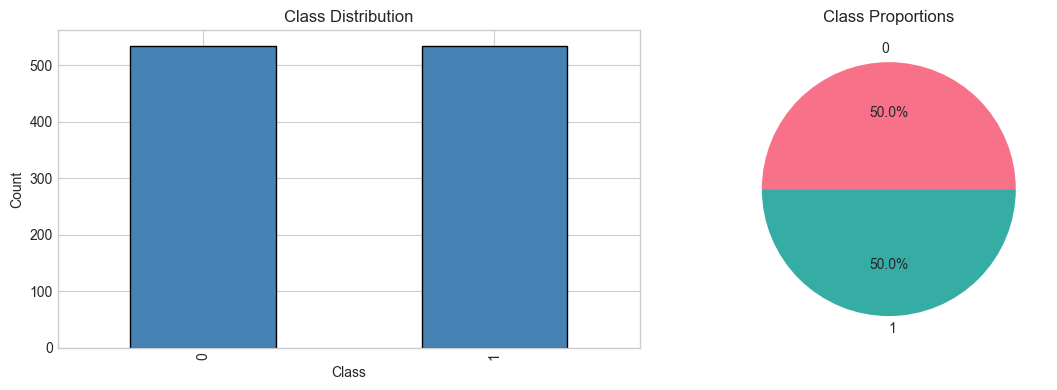

In [6]:
# Target Class Distribution
print("🎯 Target Class Distribution")
class_dist = df[TARGET_COLUMN].value_counts()
print(class_dist)
print(f"\n⚖️ Imbalance Ratio: {class_dist.max() / class_dist.min():.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')

# Pie chart
class_dist.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('husl', len(class_dist)))
axes[1].set_ylabel('')
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

## Section 3: Data Preprocessing and Feature Engineering

Handle missing values, encode categorical variables, and scale numerical features.

In [7]:
# Separate features and target
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Encode target if categorical
label_encoder = None
if y.dtype == 'object' or y.dtype.name == 'category':
    label_encoder = LabelEncoder()
    y = pd.Series(label_encoder.fit_transform(y), name=TARGET_COLUMN)
    class_names = list(label_encoder.classes_)
    print(f"✓ Target encoded: {class_names}")
else:
    class_names = [str(c) for c in sorted(y.unique())]

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"📊 Numeric features: {len(numeric_cols)}")
print(f"📊 Categorical features: {len(categorical_cols)}")

# Handle missing values for numeric columns
if len(numeric_cols) > 0:
    imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

# Handle missing values and encode categorical columns
if len(categorical_cols) > 0:
    for col in categorical_cols:
        mode_val = X[col].mode().iloc[0] if not X[col].mode().empty else 'Unknown'
        X[col] = X[col].fillna(mode_val)
    
    # One-hot encode categorical columns
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

feature_names = list(X.columns)
print(f"✓ Final features after encoding: {len(feature_names)}")

📊 Numeric features: 1604
📊 Categorical features: 1
✓ Final features after encoding: 1621


## Section 4: Train-Test Split

Split the dataset into training and testing sets with stratification to maintain class proportions.

In [8]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y.values,
    test_size=TEST_SIZE,
    stratify=y.values,
    random_state=RANDOM_STATE
)

print(f"✓ Training set: {len(X_train):,} samples ({100-TEST_SIZE*100:.0f}%)")
print(f"✓ Test set: {len(X_test):,} samples ({TEST_SIZE*100:.0f}%)")
print(f"✓ Stratified split with random_state={RANDOM_STATE}")

# Store original training data for SMOTE
X_train_original = X_train.copy()
y_train_original = y_train.copy()

✓ Training set: 856 samples (80%)
✓ Test set: 214 samples (20%)
✓ Stratified split with random_state=42


In [9]:
# Check imbalance ratio
class_counts = pd.Series(y_train).value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"⚖️ Imbalance ratio: {imbalance_ratio:.2f}")

# Apply SMOTE if imbalanced (ratio > 1.5) and library is available
APPLY_SMOTE = imbalance_ratio > 1.5 and HAS_IMBLEARN

if APPLY_SMOTE:
    print("⚠️ Imbalance detected. Applying SMOTE to training data...")
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    
    new_counts = pd.Series(y_train).value_counts()
    print(f"✓ SMOTE applied: {len(y_train_original):,} → {len(y_train):,} samples")
    print(f"✓ New class distribution:\n{new_counts}")
elif imbalance_ratio > 1.5:
    print("⚠️ Imbalance detected but imbalanced-learn not installed.")
    print("   Will use class_weight='balanced' in models instead.")
else:
    print("✓ Classes are balanced. No resampling needed.")

⚖️ Imbalance ratio: 1.00
✓ Classes are balanced. No resampling needed.


## Section 6: Build Baseline Classification Model

Establish a performance benchmark with a simple Logistic Regression model.

In [10]:
# Baseline Model: Logistic Regression
baseline_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline_model.fit(X_train, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test)
y_pred_proba_baseline = baseline_model.predict_proba(X_test)

# Evaluation
print("=" * 60)
print("📊 BASELINE MODEL: Logistic Regression")
print("=" * 60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline, average='weighted'):.4f}")

# ROC-AUC for binary classification
if len(class_names) == 2:
    roc_auc = roc_auc_score(y_test, y_pred_proba_baseline[:, 1])
    print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

📊 BASELINE MODEL: Logistic Regression

Accuracy:  0.7944
Precision: 0.7948
Recall:    0.7944
F1-Score:  0.7943
ROC-AUC:   0.8487

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       107
           1       0.81      0.78      0.79       107

    accuracy                           0.79       214
   macro avg       0.79      0.79      0.79       214
weighted avg       0.79      0.79      0.79       214



## Section 7: Implement Multiple Classification Algorithms

Train various classifiers and compare their performance.

In [11]:
# Define classifiers to train (SVM excluded - too slow on large datasets)
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=RANDOM_STATE),  # Reduced estimators
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE)  # Reduced estimators
}

# Add XGBoost if available
if HAS_XGBOOST:
    classifiers['XGBoost'] = XGBClassifier(
        n_estimators=50,  # Reduced for speed
        eval_metric='logloss', 
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        n_jobs=-1
    )

# Train all models
trained_models = {}
print("🏋️ Training Models...")
print("-" * 40)

for name, model in classifiers.items():
    print(f"  Training {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    trained_models[name] = model
    print("✓")

print(f"\n✓ Trained {len(trained_models)} models")

🏋️ Training Models...
----------------------------------------
  Training Logistic Regression... ✓
  Training Decision Tree... ✓
  Training Random Forest... ✓
  Training Gradient Boosting... ✓
  Training KNN... ✓
  Training Naive Bayes... ✓
  Training AdaBoost... ✓
  Training XGBoost... ✓

✓ Trained 8 models


## Section 8: Model Evaluation Metrics

Calculate and compare key classification metrics for all models.

In [12]:
# Evaluate all models on test set
model_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    
    # ROC-AUC
    if y_pred_proba is not None:
        if len(class_names) == 2:
            metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba[:, 1])
        else:
            try:
                metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            except:
                metrics['ROC-AUC'] = None
    else:
        metrics['ROC-AUC'] = None
    
    model_results.append(metrics)

# Create results DataFrame
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("📊 MODEL EVALUATION RESULTS")
print("=" * 80)
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model (by F1-Score): {best_model_name}")

📊 MODEL EVALUATION RESULTS
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost  0.836449   0.837895 0.836449  0.836273 0.871692
  Gradient Boosting  0.817757   0.819123 0.817757  0.817562 0.880252
           AdaBoost  0.817757   0.819123 0.817757  0.817562 0.880295
      Random Forest  0.813084   0.813084 0.813084  0.813084 0.890427
        Naive Bayes  0.799065   0.811047 0.799065  0.797112 0.810289
Logistic Regression  0.794393   0.794805 0.794393  0.794321 0.848677
      Decision Tree  0.766355   0.767852 0.766355  0.766028 0.766355
                KNN  0.705607   0.715568 0.705607  0.702167 0.786706

🏆 Best Model (by F1-Score): XGBoost


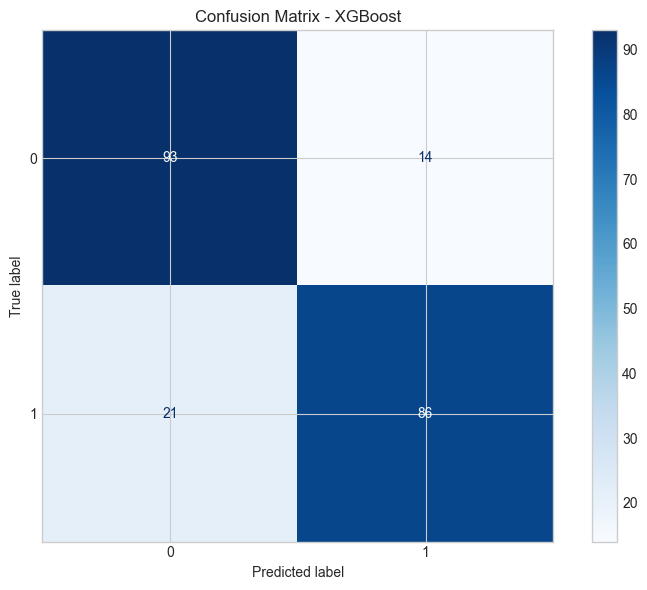

In [13]:
# Visualize Confusion Matrix for Best Model
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=class_names,
    cmap='Blues',
    ax=ax
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

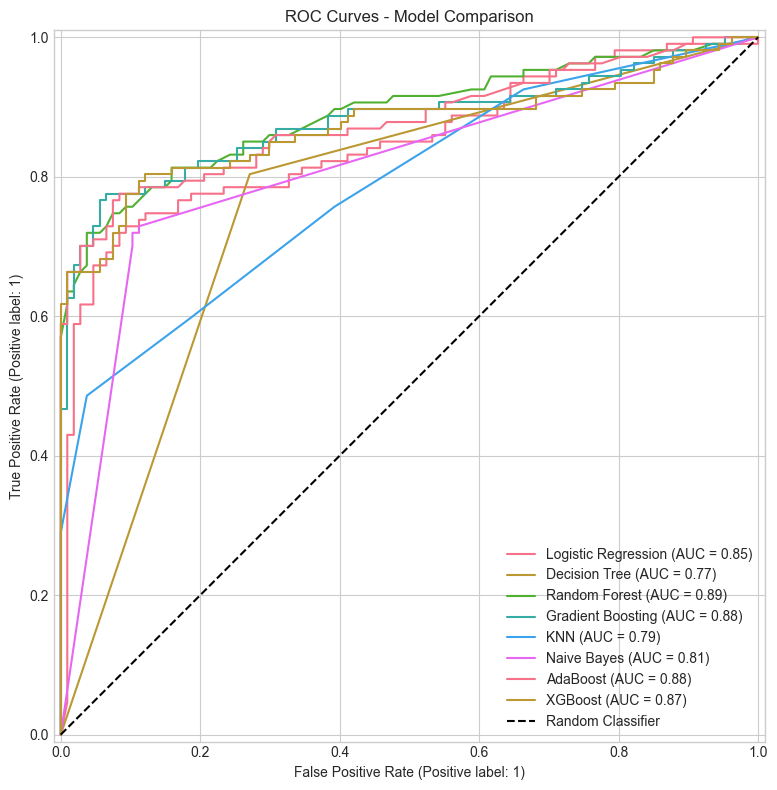

In [14]:
# ROC Curves (for binary classification)
if len(class_names) == 2:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for name, model in trained_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=ax)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.title('ROC Curves - Model Comparison')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ROC curve visualization skipped for multiclass classification")

## Section 9: Hyperparameter Tuning

Optimize the best performing model using GridSearchCV.

In [15]:
# Hyperparameter tuning for the BEST model (dynamic)
print(f"🔍 Hyperparameter Tuning: {best_model_name}")
print("-" * 50)

# Define param grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
        # Note: 'algorithm' parameter was removed in scikit-learn 1.2+
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga']
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Get the appropriate param grid and base model
if best_model_name in param_grids:
    param_grid = param_grids[best_model_name]
    base_model = classifiers[best_model_name]
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    grid_search = RandomizedSearchCV(
        base_model,
        param_grid,
        n_iter=min(20, len(param_grid)),  # Don't try more than available combinations
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    print(f"\n✓ Best Parameters: {grid_search.best_params_}")
    print(f"✓ Best CV F1-Score: {grid_search.best_score_:.4f}")
    
    # Get tuned model
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test)
    print(f"✓ Test F1-Score: {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")
else:
    print(f"⚠️ No param grid defined for {best_model_name}. Skipping tuning.")
    tuned_model = trained_models[best_model_name]

🔍 Hyperparameter Tuning: XGBoost
--------------------------------------------------
Fitting 5 folds for each of 4 candidates, totalling 20 fits

✓ Best Parameters: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}
✓ Best CV F1-Score: 0.8190
✓ Test F1-Score: 0.8316


## Section 10: Cross-Validation

Assess model stability and reduce overfitting risk using k-fold cross-validation.

🔄 Cross-Validation Results (5-Fold)
Logistic Regression      : F1 = 0.7865 (+/- 0.0508)
Decision Tree            : F1 = 0.7249 (+/- 0.0904)
Random Forest            : F1 = 0.8180 (+/- 0.1150)
Gradient Boosting        : F1 = 0.8190 (+/- 0.1194)
KNN                      : F1 = 0.7229 (+/- 0.0516)
Naive Bayes              : F1 = 0.7830 (+/- 0.0724)
AdaBoost                 : F1 = 0.8029 (+/- 0.1348)
XGBoost                  : F1 = 0.8123 (+/- 0.1168)


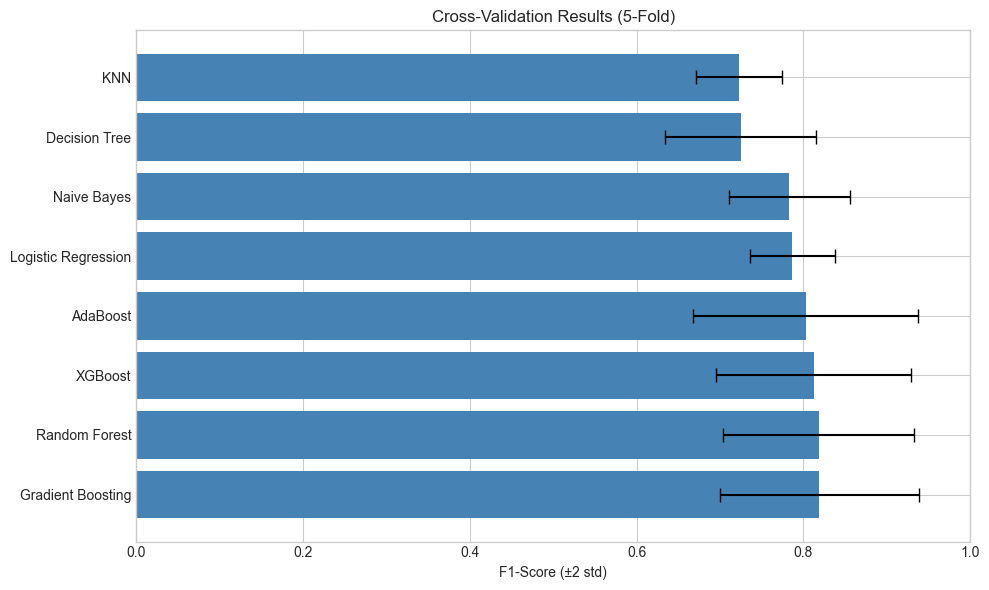

In [16]:
# Cross-validation for all models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print("🔄 Cross-Validation Results (5-Fold)")
print("=" * 60)

for name, model in trained_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    cv_results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"{name:25s}: F1 = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Visualize CV results
cv_df = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean F1': [v['mean'] for v in cv_results.values()],
    'Std': [v['std'] for v in cv_results.values()]
}).sort_values('Mean F1', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(cv_df['Model'], cv_df['Mean F1'], xerr=cv_df['Std']*2, color='steelblue', capsize=5)
plt.xlabel('F1-Score (±2 std)')
plt.title('Cross-Validation Results (5-Fold)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Section 11: Feature Importance Analysis

Extract and visualize feature importances from tree-based models to understand key predictors.

🔬 Top 20 Feature Importances (Random Forest)
--------------------------------------------------
                             Feature  Importance
           alert_degraded_count_mean    0.016341
            alert_degraded_count_std    0.015616
 evt_evt_comp_state_change_count_max    0.014114
               alert_total_count_std    0.013921
         alert_unique_components_max    0.012861
evt_evt_comp_state_change_count_mean    0.012315
               alert_total_count_max    0.011370
              alert_total_count_mean    0.011229
                hb_alertnew_last_std    0.011069
            alert_resolved_count_std    0.010464
                 hb_alertnew_avg_std    0.009475
         alert_unique_components_std    0.008529
           alert_resolved_count_mean    0.008020
         evt_tier_general_count_mean    0.007887
               hb_alertfixed_avg_std    0.007570
         evt_unique_event_types_mean    0.007412
 evt_evt_comp_state_change_count_std    0.007318
     evt_evt_alert_cha

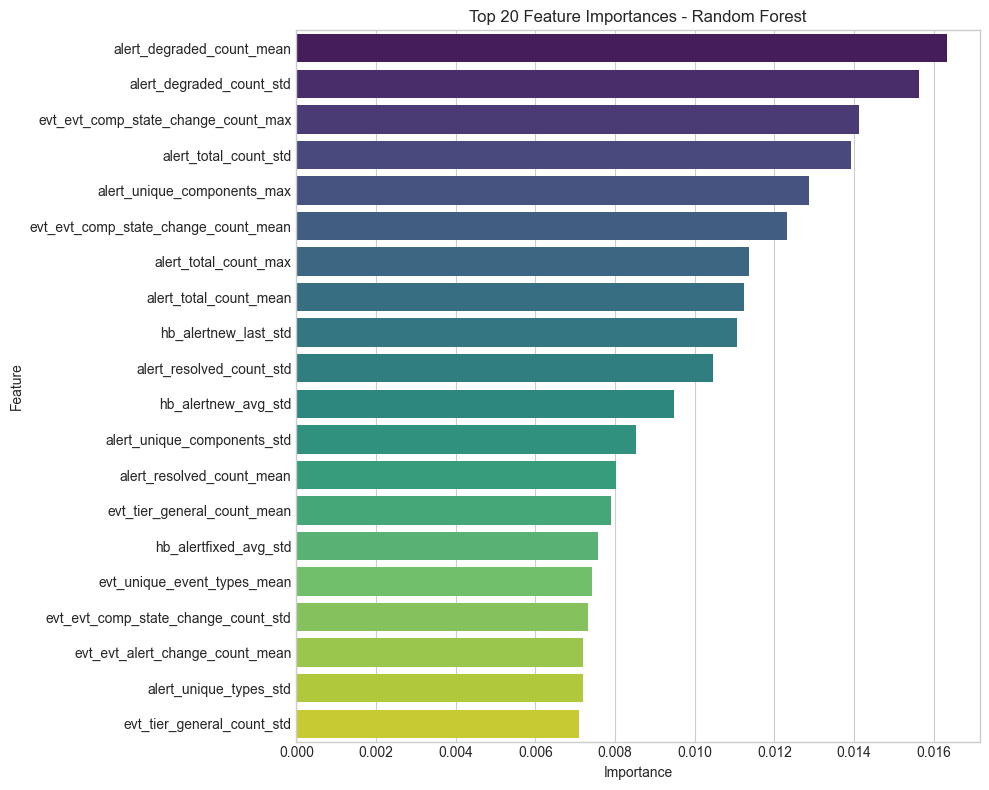


📊 Feature Importance Comparison Across Models

Random Forest Top 5: alert_degraded_count_mean, alert_degraded_count_std, evt_evt_comp_state_change_count_max, alert_total_count_std, alert_unique_components_max

Gradient Boosting Top 5: evt_evt_comp_state_change_count_max, alert_resolved_count_std, alert_degraded_count_mean, alert_degraded_count_max, memslab_slab_utilization_ratio_t2

Decision Tree Top 5: evt_evt_comp_state_change_count_max, alert_resolved_count_std, memslab_slab_utilization_ratio_t2, hb_alertnew_last_std, memslab_numslabs_std_t4

XGBoost Top 5: evt_evt_comp_state_change_count_mean, alert_degraded_count_mean, memslab_total_pages_approx_t2, memslab_numobjects_std_t4, alert_resolved_count_std


In [17]:
# Extract feature importance from Random Forest
rf_model = trained_models['Random Forest']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top 20 features
print("🔬 Top 20 Feature Importances (Random Forest)")
print("-" * 50)
print(importance_df.head(20).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(20)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis', ax=ax)
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Compare importances from multiple models
print("\n📊 Feature Importance Comparison Across Models")
tree_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
if HAS_XGBOOST and 'XGBoost' in trained_models:
    tree_models.append('XGBoost')

for model_name in tree_models:
    if model_name in trained_models:
        model = trained_models[model_name]
        if hasattr(model, 'feature_importances_'):
            top5 = pd.DataFrame({
                'Feature': feature_names,
                'Importance': model.feature_importances_
            }).nlargest(5, 'Importance')['Feature'].tolist()
            print(f"\n{model_name} Top 5: {', '.join(top5)}")

## Section 12: Model Comparison and Selection

Compare all models and select the best classifier for deployment.

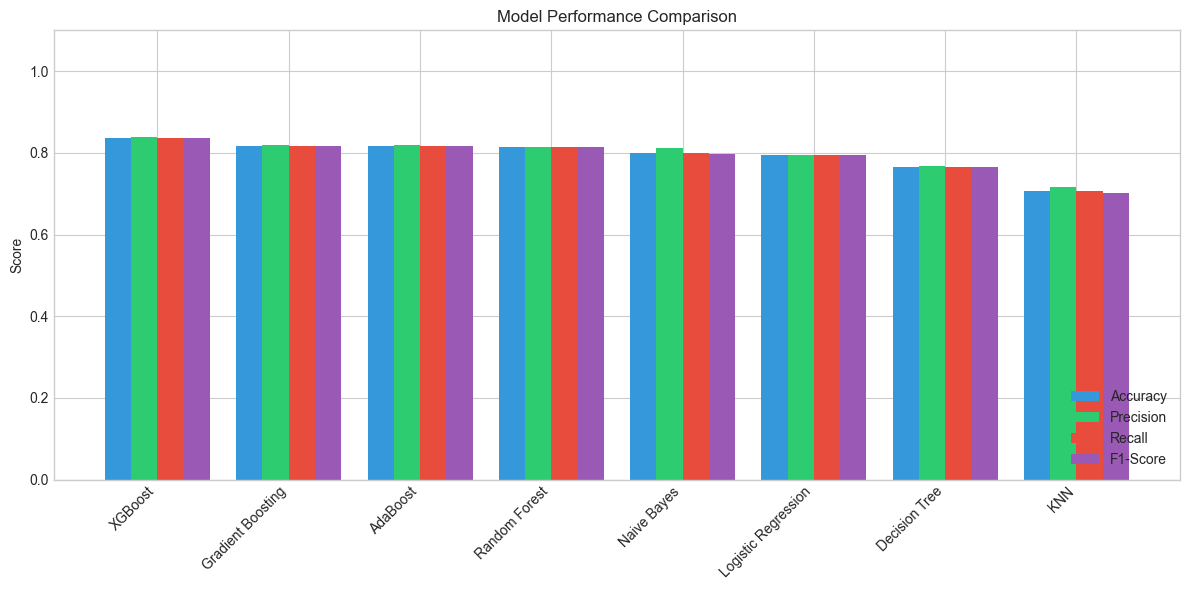


📊 FINAL MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost  0.836449   0.837895 0.836449  0.836273 0.871692
  Gradient Boosting  0.817757   0.819123 0.817757  0.817562 0.880252
           AdaBoost  0.817757   0.819123 0.817757  0.817562 0.880295
      Random Forest  0.813084   0.813084 0.813084  0.813084 0.890427
        Naive Bayes  0.799065   0.811047 0.799065  0.797112 0.810289
Logistic Regression  0.794393   0.794805 0.794393  0.794321 0.848677
      Decision Tree  0.766355   0.767852 0.766355  0.766028 0.766355
                KNN  0.705607   0.715568 0.705607  0.702167 0.786706

🏆 SELECTED MODEL: XGBoost
   Accuracy:  0.8364
   Precision: 0.8379
   Recall:    0.8364
   F1-Score:  0.8363
   ROC-AUC:   0.8717


In [18]:
# Final Model Comparison Visualization
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("📊 FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Select final model
final_model_name = results_df.iloc[0]['Model']
final_model = trained_models[final_model_name]

print(f"\n🏆 SELECTED MODEL: {final_model_name}")
print(f"   Accuracy:  {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"   Recall:    {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score:  {results_df.iloc[0]['F1-Score']:.4f}")
if results_df.iloc[0]['ROC-AUC']:
    print(f"   ROC-AUC:   {results_df.iloc[0]['ROC-AUC']:.4f}")

## Section 13: Model Persistence

Save the trained model and preprocessing objects for deployment.

In [19]:
# Save model and preprocessing artifacts
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save best model
model_filename = f'classifier_{final_model_name.lower().replace(" ", "_")}_{timestamp}.joblib'
joblib.dump(final_model, model_filename)
print(f"✓ Model saved: {model_filename}")

# Save scaler
scaler_filename = f'scaler_{timestamp}.joblib'
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved: {scaler_filename}")

# Save label encoder if used
if label_encoder:
    encoder_filename = f'label_encoder_{timestamp}.joblib'
    joblib.dump(label_encoder, encoder_filename)
    print(f"✓ Label encoder saved: {encoder_filename}")

# Save feature names
features_filename = f'feature_names_{timestamp}.txt'
with open(features_filename, 'w') as f:
    f.write('\n'.join(feature_names))
print(f"✓ Feature names saved: {features_filename}")

# Save model comparison results
results_filename = f'model_comparison_{timestamp}.csv'
results_df.to_csv(results_filename, index=False)
print(f"✓ Results saved: {results_filename}")

print(f"\n📦 All artifacts saved successfully!")

✓ Model saved: classifier_xgboost_20260311_151845.joblib
✓ Scaler saved: scaler_20260311_151845.joblib
✓ Feature names saved: feature_names_20260311_151845.txt
✓ Results saved: model_comparison_20260311_151845.csv

📦 All artifacts saved successfully!


## Section 14: Inference Helper

Use this section to make predictions on new data.

In [ ]:
# Function to make predictions on new data
def predict_new_data(new_data: pd.DataFrame, model=None, scaler_obj=None, encoder=None):
    """
    Make predictions on new data using the trained model.
    
    Args:
        new_data: DataFrame with same features as training data
        model: Trained classifier (default: final_model)
        scaler_obj: Fitted scaler (default: scaler)
        encoder: Fitted label encoder (default: label_encoder)
    
    Returns:
        Predicted class labels
    """
    if model is None:
        model = final_model
    if scaler_obj is None:
        scaler_obj = scaler
    if encoder is None:
        encoder = label_encoder
    
    # Scale features
    X_new_scaled = scaler_obj.transform(new_data)
    
    # Predict
    predictions = model.predict(X_new_scaled)
    
    # Decode if encoder was used
    if encoder:
        predictions = encoder.inverse_transform(predictions)
    
    return predictions

# Example usage (uncomment to test):
# new_df = pd.read_csv("new_data.csv")
# predictions = predict_new_data(new_df)
# print(predictions)

print("✅ Inference helper function ready!")
print("   Usage: predictions = predict_new_data(new_dataframe)")